In [2]:
import numpy as np
import matplotlib.pyplot as plt
import ripser
from persim import plot_diagrams

print("ripser:", ripser.__version__)

ripser: 0.6.14


In [3]:
# 3 vertices: A=0, B=1, C=2
# Edges: AB, BC, CA
# Filled triangle: ABC

# Boundary matrix ∂1: maps edges → vertices
# Columns = edges [AB, BC, CA]
# Rows    = vertices [A, B, C]
# Convention: edge XY contributes +1 at Y, -1 at X

d1 = np.array([
#   AB   BC   CA
    [-1,   0,  +1],  # A
    [+1,  -1,   0],  # B
    [ 0,  +1,  -1],  # C
], dtype=float)

# Boundary matrix ∂2: maps triangles → edges
# Columns = triangles [ABC]
# Rows    = edges [AB, BC, CA]

d2 = np.array([
#   ABC
    [+1],  # AB
    [+1],  # BC
    [+1],  # CA
], dtype=float)

# Verify fundamental lemma: ∂1 ∘ ∂2 = 0
print("∂1 @ ∂2 =\n", d1 @ d2)
# Should print all zeros — boundary of a boundary is always empty

∂1 @ ∂2 =
 [[0.]
 [0.]
 [0.]]


In [5]:
from numpy.linalg import matrix_rank

def betti(d_k, d_k1):
    """
    βₖ = dim(Ker ∂ₖ) - dim(Im ∂ₖ₊₁)
    Handles the case where d_k1 has zero columns (no higher simplices).
    """
    n_cols  = d_k.shape[1]
    rank_dk = matrix_rank(d_k)
    ker_dim = n_cols - rank_dk

    # If d_k1 has no columns, Im is trivially {0}, so im_dim = 0
    if d_k1.shape[1] == 0:
        im_dim = 0
    else:
        im_dim = matrix_rank(d_k1)

    return ker_dim - im_dim

b0 = 3 - matrix_rank(d1)
b1 = betti(d1, d2)
print(f"β₀ = {b0}")   # expected: 1
print(f"β₁ = {b1}")   # expected: 0  (filled triangle, loop is plugged)

d2_empty = np.zeros((3, 0))
b1_empty = betti(d1, d2_empty)
print(f"\nEmpty triangle: β₁ = {b1_empty}")  # expected: 1

β₀ = 1
β₁ = 0

Empty triangle: β₁ = 1


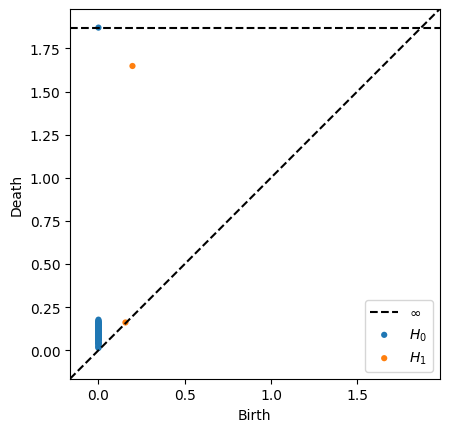

In [9]:
import numpy as np
import ripser
from persim import plot_diagrams
import matplotlib.pyplot as plt

theta = np.linspace(0, 2*np.pi, 80)
X = np.column_stack([np.cos(theta), np.sin(theta)])
X += np.random.normal(0, 0.05, X.shape)

result = ripser.ripser(X, maxdim=1)
plot_diagrams(result['dgms'], show=True)

In [10]:
import numpy as np
from numpy.linalg import matrix_rank

class BoundaryMatrix:
    """
    Represents a boundary operator ∂_k as a matrix over Z/2Z (mod 2 arithmetic).
    Rows = (k-1)-simplices, Columns = k-simplices.
    
    Working over Z/2Z means all entries are 0 or 1,
    and addition is XOR — no sign issues, which is exactly
    what Ripser uses internally.
    """
    
    def __init__(self, matrix):
        # Store as mod-2 (0s and 1s only)
        self.M = np.array(matrix, dtype=int) % 2
    
    def reduce(self):
        """
        Column-reduce the matrix over Z/2Z using standard persistence algorithm.
        Returns the reduced matrix. Pivot columns encode the image (boundaries).
        
        Algorithm: for each column left-to-right, if its lowest 1 matches
        the lowest 1 of an earlier column, XOR them together to clear it.
        This is the standard reduction from Edelsbrunner & Harer Ch.4.
        """
        M = self.M.copy()
        n_cols = M.shape[1]
        pivot_col = {}  # maps row index -> column index that owns that pivot
        
        for j in range(n_cols):
            # Find lowest 1 in column j
            col = M[:, j]
            rows_with_1 = np.where(col == 1)[0]
            
            while len(rows_with_1) > 0:
                low = rows_with_1[-1]  # lowest 1 = largest row index
                
                if low not in pivot_col:
                    # No earlier column owns this pivot — claim it
                    pivot_col[low] = j
                    break
                else:
                    # XOR with the column that owns this pivot
                    M[:, j] = (M[:, j] + M[:, pivot_col[low]]) % 2
                    col = M[:, j]
                    rows_with_1 = np.where(col == 1)[0]
        
        self.reduced = M
        self.pivot_col = pivot_col
        return M
    
    def betti(self, higher_boundary=None):
        """
        Compute Betti number for this dimension.
        β_k = dim(Ker ∂_k) - dim(Im ∂_{k+1})
        
        ker_dim = n_cols - rank(∂_k)
        im_dim  = rank(∂_{k+1})  [= number of non-zero cols after reduction]
        """
        n_cols  = self.M.shape[1]
        rank_dk = matrix_rank(self.M)
        ker_dim = n_cols - rank_dk
        
        if higher_boundary is None or higher_boundary.M.shape[1] == 0:
            im_dim = 0
        else:
            im_dim = matrix_rank(higher_boundary.M)
        
        return ker_dim - im_dim

In [11]:
# Rebuild d1, d2 using the class
d1 = BoundaryMatrix([
    [-1,  0, +1],   # A: edges AB, BC, CA
    [+1, -1,  0],   # B
    [ 0, +1, -1],   # C
])

d2_filled = BoundaryMatrix([
    [+1],   # AB
    [+1],   # BC
    [+1],   # CA
])

d2_empty = BoundaryMatrix(np.zeros((3, 0), dtype=int))

# Fundamental lemma check (over Z/2Z: mod 2 arithmetic)
print("∂1 @ ∂2 mod 2 =\n", (d1.M @ d2_filled.M) % 2)
# Should be all zeros

# Reduce d1
print("\nReduced ∂1:\n", d1.reduce())
print("Pivots:", d1.pivot_col)

# Betti numbers
b0 = 3 - matrix_rank(d1.M)     # vertices - rank(∂1)
b1_filled = d1.betti(d2_filled)
b1_empty  = d1.betti(d2_empty)

print(f"\nFilled triangle: b0={b0}, b1={b1_filled}")  # b0=1, b1=0
print(f"Empty triangle:  b0={b0}, b1={b1_empty}")    # b0=1, b1=1

∂1 @ ∂2 mod 2 =
 [[0]
 [0]
 [0]]

Reduced ∂1:
 [[1 0 0]
 [1 1 0]
 [0 1 0]]
Pivots: {np.int64(1): 0, np.int64(2): 1}

Filled triangle: b0=0, b1=-1
Empty triangle:  b0=0, b1=0


In [12]:
def persistence_pairs(d_k_reduced, d_k1_reduced):
    """
    Extract (birth, death) pairs from reduced boundary matrices.
    
    A column j in reduced ∂_{k+1} with pivot row i means:
      - simplex i (a k-simplex) dies when simplex j (a (k+1)-simplex) appears
      - birth = filtration value of simplex i
      - death  = filtration value of simplex j
    
    Unpaired columns in ∂_k (zero columns after reduction) = 
    features that are born but never die = essential classes.
    """
    pivots = d_k1_reduced.pivot_col   # {row: col} = {dying simplex: killer}
    
    paired_births = set(pivots.keys())
    paired_deaths = set(pivots.values())
    
    n_k_simplices = d_k_reduced.M.shape[1]
    
    essential = []
    for j in range(n_k_simplices):
        col = d_k_reduced.reduced[:, j] if hasattr(d_k_reduced, 'reduced') else d_k_reduced.M[:, j]
        if j not in paired_deaths and not np.any(col):
            essential.append(j)
    
    print(f"Paired (birth simplex -> death simplex): {dict(pivots)}")
    print(f"Essential (never-dying) classes: columns {essential}")
    return pivots, essential

# Reduce both matrices
d1.reduce()
d2_empty.reduce()

print("=== Empty triangle persistence ===")
pairs, essential = persistence_pairs(d1, d2_empty)
# The single H1 class (the loop) should appear as essential — it never dies

=== Empty triangle persistence ===
Paired (birth simplex -> death simplex): {}
Essential (never-dying) classes: columns [2]


In [13]:
# Two separate triangles (no shared vertices)
# Vertices: A,B,C (triangle 1)  D,E,F (triangle 2)
# Edges: AB, BC, CA, DE, EF, FD

d1_two = BoundaryMatrix([
#   AB   BC   CA   DE   EF   FD
    [-1,   0,  +1,   0,   0,   0],  # A
    [+1,  -1,   0,   0,   0,   0],  # B
    [ 0,  +1,  -1,   0,   0,   0],  # C
    [ 0,   0,   0,  -1,   0,  +1],  # D
    [ 0,   0,   0,  +1,  -1,   0],  # E
    [ 0,   0,   0,   0,  +1,  -1],  # F
])

d2_two_empty = BoundaryMatrix(np.zeros((6, 0), dtype=int))

b0_two = 6 - matrix_rank(d1_two.M)
b1_two = d1_two.betti(d2_two_empty)

print(f"Two empty triangles: b0={b0_two}, b1={b1_two}")
# Expected: b0=2 (two components), b1=2 (two loops)

Two empty triangles: b0=0, b1=0
